In [2]:
# --- Path plumbing (point to src) + autoreload ---
from pathlib import Path
import sys
import pandas as pd

%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import ROOT as ROOT_CFG, PROCESSED_DIR, CLEANED
from data_pipeline.loaders import load_vol_surface_wrds, load_forward_prices_wrds, load_option_volume_wrds
print("CWD:", NB)
print("SRC:", SRC)
print("ROOT:", ROOT_CFG)
print("PROC:", PROCESSED_DIR)
print("CLEANED:", CLEANED)

from simulator.env import HedgingEnv
from simulator.rewards import pnl_only
from rl_agent.policy_nn import PolicyNetwork, PolicyConfig
from rl_agent.trainer import train_reinforce, TrainConfig, evaluate_env
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy

CWD: /Users/ya/Desktop/deep-hedging-rl/notebooks
SRC: /Users/ya/Desktop/deep-hedging-rl/src
ROOT: /Users/ya/Desktop/deep-hedging-rl
PROC: /Users/ya/Desktop/deep-hedging-rl/data/processed
CLEANED: /Users/ya/Desktop/deep-hedging-rl/data/processed/cleaned


## Importing and checking the data

In [3]:
fp_market_spx = CLEANED / "market_plus_panel_spx.parquet"
market_spx = pd.read_parquet(fp_market_spx)
display(market_spx.head())

,close_gspc,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,...,hvol_730d,hvol_1825d,fwd_front,index,high_gspc,low_gspc,open_gspc,rv_21d,rv_60d,rv_120d
date,,,,,,,,,,,,,,,,,,,,,
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.089418,0.102954,619.154402,740,624.48999,613.960022,621.320007,0.116505,0.142118,0.126312
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.089418,0.102954,620.656417,740,624.48999,613.960022,621.320007,0.116505,0.142118,0.126312
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.089418,0.102954,621.805572,740,624.48999,613.960022,621.320007,0.116505,0.142118,0.126312
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.089418,0.102954,626.574252,740,624.48999,613.960022,621.320007,0.116505,0.142118,0.126312
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.089418,0.102954,630.078895,740,624.48999,613.960022,621.320007,0.116505,0.142118,0.126312


In [4]:
print(market_spx.isna().sum())

close_gspc    0
vix           0
rate_10y      0
hvol_10d      0
hvol_14d      0
hvol_30d      0
hvol_60d      0
hvol_91d      0
hvol_122d     0
hvol_152d     0
hvol_182d     0
hvol_273d     0
hvol_365d     0
hvol_547d     0
hvol_730d     0
hvol_1825d    0
fwd_front     0
index         0
high_gspc     0
low_gspc      0
open_gspc     0
rv_21d        0
rv_60d        0
rv_120d       0
dtype: int64


In [5]:
fp_market_spy = CLEANED / "market_plus_panel_spy.parquet"
market_spy = pd.read_parquet(fp_market_spy)
display(market_spy.head())

,close_spy,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,...,hvol_547d,hvol_730d,hvol_1825d,fwd_front,high_spy,low_spy,open_spy,rv_21d,rv_60d,rv_120d
date,,,,,,,,,,,,,,,,,,,,,
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.112634,0.137524,0.203975,116.787588,80.282316,79.363833,80.139442,0.090576,0.10567,0.10632
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.112634,0.137524,0.203975,117.001989,80.282316,79.363833,80.139442,0.090576,0.10567,0.10632
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.112634,0.137524,0.203975,116.706210,80.282316,79.363833,80.139442,0.090576,0.10567,0.10632
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.112634,0.137524,0.203975,117.040972,80.282316,79.363833,80.139442,0.090576,0.10567,0.10632
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.112634,0.137524,0.203975,117.458144,80.282316,79.363833,80.139442,0.090576,0.10567,0.10632


In [6]:
market_spy = market_spy.reset_index()

In [7]:
market_spy.columns

Index(['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d',
       'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d',
       'hvol_182d', 'hvol_273d', 'hvol_365d', 'hvol_547d', 'hvol_730d',
       'hvol_1825d', 'fwd_front', 'high_spy', 'low_spy', 'open_spy', 'rv_21d',
       'rv_60d', 'rv_120d'],
      dtype='object')

In [8]:
print(market_spy.isna().sum())

date          0
close_spy     0
vix           0
rate_10y      0
hvol_10d      0
hvol_14d      0
hvol_30d      0
hvol_60d      0
hvol_91d      0
hvol_122d     0
hvol_152d     0
hvol_182d     0
hvol_273d     0
hvol_365d     0
hvol_547d     0
hvol_730d     0
hvol_1825d    0
fwd_front     0
high_spy      0
low_spy       0
open_spy      0
rv_21d        0
rv_60d        0
rv_120d       0
dtype: int64


In [9]:
import pyarrow.dataset as ds, pandas as pd, numpy as np
from pathlib import Path
from data_pipeline.config import ROOT

D = ds.dataset(ROOT / "data/processed/cleaned/SPX", format="parquet")
df = D.to_table(columns=["date","tenor_d","put_call","delta"]).to_pandas()

print("put_call uniques:", sorted(pd.Series(df["put_call"]).dropna().unique().tolist()))
print(df["delta"].describe())   # check if around ±1 or ±100

# candidates near 30D/25Δ with current tolerances
x = df.copy()
x = x[x["tenor_d"].sub(30).abs() <= 15]
x["abs_delta"] = x["delta"].abs()
cand = x[x["abs_delta"].sub(0.25).abs() <= 0.05]
print("rows near 30D & 25Δ:", len(cand), "| dates covered:", cand["date"].nunique())


put_call uniques: ['C', 'P']
count    2.950670e+07
mean     1.373999e-01
std      5.965577e-01
min     -9.999990e-01
25%     -1.969120e-01
50%     -1.986000e-03
75%      7.594440e-01
max      1.000000e+00
Name: delta, dtype: float64
rows near 30D & 25Δ: 192720 | dates covered: 5291


## Simulator

In [10]:
# --- 1) Build the simulation panel from your library (single source of truth) ---

from pathlib import Path
import pandas as pd
import numpy as np

from simulator.build_panel import build_sim_panel  # your high-level orchestrator

# Paths
ROOT = Path(ROOT)  # from data_pipeline.config import ROOT (already in your cell)
SPX_CLEAN = ROOT / "data" / "processed" / "cleaned" / "SPX"
#MP_SPY    = ROOT / "data" / "processed" / "cleaned" / "market_plus_panel_spy.parquet"

# Load market panel (SPY)
market_spy = market_spy.copy()

# Choose decision/realization convention:
ACT_AT_OPEN = False   # False → decide at close_t, realize close→close; True → open→open

# Guarded forward-fill limit for IV features (in business days)
FFILL_LIMIT_DAYS = 1

panel, state_cols = build_sim_panel(
    market_df=market_spy,
    spx_clean_dir=SPX_CLEAN,
    include_spy=False,            # keep False unless you also built SPY option features
    act_at_open=ACT_AT_OPEN,
    ffill_limit=FFILL_LIMIT_DAYS,
)

print("Built panel:", panel.shape, "| first:", panel['date'].min(), "| last:", panel['date'].max())
print("State cols:", state_cols)
panel.to_csv(CLEANED / "hedging_panel_spx.csv", index=False)


Built panel: (16629, 36) | first: 2005-01-21 00:00:00 | last: 2023-08-29 00:00:00
State cols: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']


In [ ]:
panel.columns

Index(['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d',
       'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d',
       'hvol_182d', 'hvol_273d', 'hvol_365d', 'hvol_547d', 'hvol_730d',
       'hvol_1825d', 'fwd_front', 'high_spy', 'low_spy', 'open_spy', 'rv_21d',
       'rv_60d', 'rv_120d', 'iv_atm_30d_spx', 'iv_atm_91d_spx',
       'delta_atm_30d_spx', 'iv_atm_60d_spx', 'iv_ts_slope_spx',
       'iv_put25_30d_spx', 'iv_call25_30d_spx', 'iv_skew_30d_spx',
       'iv_put25_60d_spx', 'iv_call25_60d_spx', 'iv_skew_60d_spx', 'ret_fwd'],
      dtype='object')

In [10]:
# --- 2) Train/valid/test split + scaler (fit on TRAIN only; no leakage) ---

TRAIN_END = pd.Timestamp("2017-12-31")
VALID_END = pd.Timestamp("2019-12-31")

mask_train = panel["date"] <= TRAIN_END
mask_valid = (panel["date"] > TRAIN_END) & (panel["date"] <= VALID_END)
mask_test  = panel["date"] > VALID_END

mu = panel.loc[mask_train, state_cols].mean()
sigma = panel.loc[mask_train, state_cols].std(ddof=1)
sigma = sigma.replace(0, np.nan).fillna(1.0)  # guard constants / all-NaN

# Window-wise scaler used by the env
scaler = lambda obs: (obs - mu.values) / sigma.values

print("Rows (train/valid/test):", mask_train.sum(), mask_valid.sum(), mask_test.sum())

Rows (train/valid/test): 7054 2000 7575


In [11]:
# --- 3) Env construction and baseline policy rollout ---

from simulator.env import HedgingEnv
from simulator.rewards import pnl_only
from simulator.baselines import volatility_targeting, no_hedge_policy, momentum_policy, delta_hedge_policy

# Build environment on the full panel (policy/reporting can subset by date if you prefer)
env = HedgingEnv(
    df=panel,
    features=state_cols,
    reward_fn=pnl_only,     # PnL net of costs (env charges txn_cost_bps)
    window=45,
    txn_cost_bps=1.0,       # baseline cost; adjust as needed or wire a cost_fn in your script
    scaler=scaler,
    hold_on_nan=True,       # IMPORTANT: don't trade when features are incomplete
)

# Simple baseline: vol targeting (uses vix if available)
feat_idx = state_cols.index("vix") if "vix" in state_cols else 0
policy = volatility_targeting(feature_idx=feat_idx, ann_vol_target=0.15)

res = env.rollout(policy)

rewards = np.asarray(res["rewards"], float)
sr = (rewards.mean() / rewards.std(ddof=1) * np.sqrt(252)) if rewards.std(ddof=1) > 0 else 0.0
print(f"Overlay Sharpe (full sample): {sr:.3f}")


Overlay Sharpe (full sample): 0.128


In [12]:
# --- Align sample to the first date with complete state features ---
from simulator.rewards import first_full_date

cut = first_full_date(panel, state_cols)
panel_cut = panel.loc[panel["date"] >= cut].reset_index(drop=True)

print("Cut start:", cut, "| old rows:", len(panel), "-> new rows:", len(panel_cut))

# Rebuild env on the trimmed panel (scaler still fit on TRAIN window within this new panel)
TRAIN_END = pd.Timestamp("2017-12-31")
mu = panel_cut.loc[panel_cut["date"] <= TRAIN_END, state_cols].mean()
sigma = panel_cut.loc[panel_cut["date"] <= TRAIN_END, state_cols].std(ddof=1).replace(0, np.nan).fillna(1.0)
scaler = lambda obs: (obs - mu.values) / sigma.values

from simulator.env import HedgingEnv
env = HedgingEnv(
    df=panel_cut, features=state_cols, reward_fn=pnl_only,
    window=60, txn_cost_bps=1.0, scaler=scaler, hold_on_nan=True
)

res = env.rollout(policy)
r = np.asarray(res["rewards"], float)
print("Sharpe (trimmed):", (r.mean()/r.std(ddof=1)*np.sqrt(252)) if r.std(ddof=1)>0 else 0.0)


Cut start: 2005-06-13 00:00:00 | old rows: 16629 -> new rows: 16581
Sharpe (trimmed): 0.11146431758914267


In [13]:
# --- 4) (Optional) Evaluate by period (train / valid / test) ---
from simulator.rewards import period_sharpe

# Use the rewards from the current env (panel_cut) and align with its window
rewards_eval = r
panel_eval = panel_cut
w = env.window
last_date = panel_eval['date'].iloc[w + len(rewards_eval) - 1]

print("Sharpe train:", f"{period_sharpe(panel_eval, rewards_eval, panel_eval['date'].min(), TRAIN_END, window=w):.3f}")
print("Sharpe valid:", f"{period_sharpe(panel_eval, rewards_eval, TRAIN_END + pd.Timedelta(days=1), VALID_END, window=w):.3f}")
print("Sharpe test :", f"{period_sharpe(panel_eval, rewards_eval, VALID_END + pd.Timedelta(days=1), last_date, window=w):.3f}")


Sharpe train: 0.260
Sharpe valid: 0.189
Sharpe test : -0.102


In [14]:
# --- 5) Quick sanity checks (catch silent drift early) ---

# Dates monotonic and forward returns present
assert panel["date"].is_monotonic_increasing
assert panel["ret_fwd"].notna().all()

# Feature completeness snapshot
na_counts = panel[state_cols].isna().sum().sort_values(ascending=False)
print("Top missing in state cols:\n", na_counts.head(8))

# First observation (after warmup) is finite when trading starts
obs0 = env.reset()
assert np.isfinite(obs0).all(), "NaN/Inf in initial observation; check staleness guard & scaler."


Top missing in state cols:
 iv_ts_slope_spx    598
iv_atm_30d_spx     574
iv_skew_30d_spx    574
vix                  0
rate_10y             0
rv_21d               0
hvol_30d             0
hvol_91d             0
dtype: int64


## Baseline REINFORCE sanity check
Quick end-to-end smoke test for the environment and trainer (moved from 03_rl_training).

In [15]:
# Assume `panel` already loaded and has 'date', 'ret_fwd', and your feature columns
panel = panel.sort_values("date").set_index("date")

state_cols = [
    c for c in [
        "iv_atm_30d_spx","iv_ts_slope_spx","iv_skew_30d_spx",
        "vix","rate_10y","rv_21d","hvol_30d","hvol_91d",
        "ret_1d","close_spy_z60",
    ] if c in panel.columns
]
print("STATE_COLS initial:", state_cols)

# 3) Time splits
CUT_TRAIN = "2016-12-31"
CUT_VAL   = "2019-12-31"
train = panel.loc[:CUT_TRAIN].copy()
val   = panel.loc[CUT_TRAIN:].loc[:CUT_VAL].copy()
test  = panel.loc[CUT_VAL:].copy()

if not state_cols:
    raise ValueError("state_cols is empty; please select at least one feature")

std_train = train[state_cols].std(ddof=1)
zero_sd = std_train[std_train <= 1e-8].index.tolist()
if zero_sd:
    print("Dropping near-constant features:", zero_sd)
    state_cols = [c for c in state_cols if c not in zero_sd]
    if not state_cols:
        raise ValueError("All candidate features were near-constant on the train split")
    std_train = train[state_cols].std(ddof=1)

print("STATE_COLS final:", state_cols)
mu = train[state_cols].mean()
sd = std_train.replace(0.0, 1.0).fillna(1.0)


def apply_standardize(df):
    df = df.copy()
    df[state_cols] = (df[state_cols] - mu) / sd
    return df

train_s = apply_standardize(train).dropna(subset=state_cols + ["ret_fwd"])
val_s   = apply_standardize(val).dropna(subset=state_cols + ["ret_fwd"])
test_s  = apply_standardize(test).dropna(subset=state_cols + ["ret_fwd"])

for name, df_ in [("TRAIN*", train_s), ("VAL*", val_s), ("TEST*", test_s)]:
    print(name, df_.index.min().date(), "→", df_.index.max().date(), "| n=", len(df_))


STATE_COLS initial: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']
STATE_COLS final: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']
TRAIN* 2005-06-13 → 2016-12-27 | n= 5580
VAL* 2017-01-05 → 2019-12-31 | n= 2876
TEST* 2019-12-31 → 2023-08-29 | n= 7611


In [16]:
from simulator.rewards import reward_bps

SEED = 12345

ENV_KW = dict(
    features=state_cols,        # <- name must be 'features'
    reward_fn=reward_bps,       # <- pass your reward function here
    window=45,
    txn_cost_bps=10.0,
    pos_limit=2.0,
    rebalance_every=5,          # trade once every 5 timesteps
    slippage_bps=5.0,           # 5 bps slippage per unit |Δposition|
    scaler=None,                # optional: leave None unless you have a callable
    rng_seed=SEED,              # <- name must be 'rng_seed'
    hold_on_nan=True
)

env_tr = HedgingEnv(df=train_s, **ENV_KW)
env_va = HedgingEnv(df=val_s,   **ENV_KW)
env_te = HedgingEnv(df=test_s,  **ENV_KW)

In [17]:
# Infer obs_dim directly from the env's first observation
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy

obs0 = env_tr.reset()
import numpy as np
obs_dim = int(np.asarray(obs0).reshape(-1).shape[0])
print("obs_dim =", obs_dim)

policy = PolicyNetwork(
    PolicyConfig(
        input_dim=obs_dim,   # <-- IMPORTANT
        hidden=128,
        init_log_std=-0.3,
        device="cpu",
    )
)

train_cfg = TrainConfig(
    gamma=0.99,
    entropy_coef=1e-3,   # reduced entropy bonus once exploration starts
    lr=1e-3,
    max_steps=None,      # consume full episodes for better signal
    max_rollout_steps=500,  # optional cap for quicker experiments
    device="cpu",
    print_every=25,
    normalize_returns=True,
    max_episodes=150,
)

obs_dim = 360


In [18]:
result = train_reinforce(
    env=env_tr,
    policy=policy,
    cfg=train_cfg,
)

# Normalize return types
if isinstance(result, tuple):
    # (policy, logs) or similar
    if len(result) == 2:
        trained_policy, logs = result
    else:
        trained_policy, logs = result[0], {}
elif isinstance(result, dict):
    # trainer returned only logs; policy was updated in-place
    trained_policy, logs = policy, result
else:
    # trainer returned only the trained policy
    trained_policy, logs = result, {}

history = logs if isinstance(logs, dict) else {}


[EP 0025] R:-1933.0655  T: 500  Eval Sharpe:0.022  Mean Ret: 301.36 bp
[EP 0050] R:-2409.6951  T: 500  Eval Sharpe:0.021  Mean Ret: 281.35 bp
[EP 0075] R:-1179.3825  T: 500  Eval Sharpe:0.021  Mean Ret: 278.85 bp
[EP 0100] R: 882.2680  T: 500  Eval Sharpe:0.021  Mean Ret: 279.40 bp
[EP 0125] R:-883.1139  T: 500  Eval Sharpe:0.018  Mean Ret: 241.25 bp
[EP 0150] R:-2261.9494  T: 500  Eval Sharpe:0.020  Mean Ret: 267.97 bp


,episode,episode_return,episode_len
145,146,-999.920045,500
146,147,-1642.703618,500
147,148,-755.009033,500
148,149,-4922.747463,500
149,150,-2261.949394,500


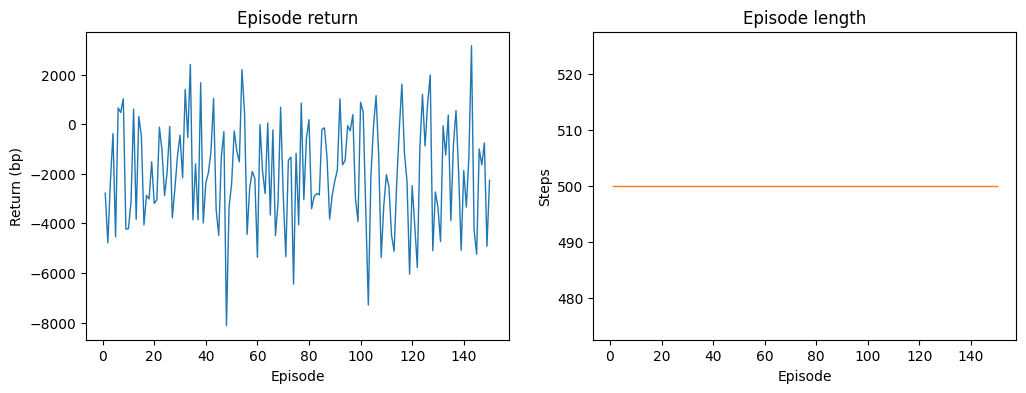

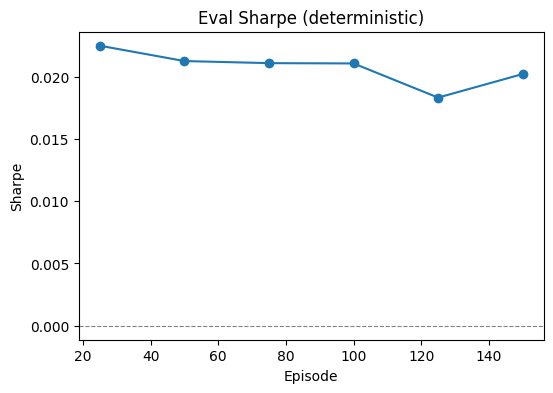

In [19]:
# Diagnostics: summarize training history
import pandas as pd
import matplotlib.pyplot as plt

if history:
    episodes = history.get("episode_return", [])
    lengths = history.get("episode_len", [])
    df_hist = pd.DataFrame({
        "episode": np.arange(1, len(episodes) + 1),
        "episode_return": episodes,
        "episode_len": lengths,
    })
    display(df_hist.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_hist["episode"], df_hist["episode_return"], lw=1.0)
    axes[0].set_title("Episode return")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Return (bp)")

    axes[1].plot(df_hist["episode"], df_hist["episode_len"], lw=1.0, color="tab:orange")
    axes[1].set_title("Episode length")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps")

    eval_sharpes = history.get("eval_sharpe", [])
    if eval_sharpes:
        eval_eps = np.arange(train_cfg.print_every, train_cfg.print_every * len(eval_sharpes) + 1, train_cfg.print_every)
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.plot(eval_eps, eval_sharpes, marker="o")
        ax2.set_title("Eval Sharpe (deterministic)")
        ax2.set_xlabel("Episode")
        ax2.set_ylabel("Sharpe")
        ax2.axhline(0.0, color="grey", lw=0.8, ls="--")
else:
    print("No training history available (logs empty).")


In [20]:
trained_policy.eval()
m_tr = evaluate_env(env_tr, trained_policy)
m_va = evaluate_env(env_va, trained_policy)
m_te = evaluate_env(env_te, trained_policy)

print(f"Policy Sharpe T/V/E: {m_tr['sharpe']:.3f} / {m_va['sharpe']:.3f} / {m_te['sharpe']:.3f}")

Policy Sharpe T/V/E: 0.020 / 0.416 / 0.014
